# P3 · 02 — Conformal prediction & adaptive conformal inference

**Conformal prediction** turns *any* point model into intervals with a
**distribution-free, finite-sample coverage guarantee** — no Gaussian assumption.
The recipe (split conformal):

1. Fit a point model on a *proper-training* set.
2. On a held-out **calibration** set, collect the residuals.
3. The interval is `prediction ± (1-α) empirical quantile of |residual|`.

Under **exchangeability**, that interval covers the truth with prob ≥ 1-α. We
calibrate the residual quantile **per horizon** and in **log space** (→ a
multiplicative band, right for GDP).

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))
warnings.filterwarnings("ignore")
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from src import classical as C, probabilistic as P
q = data.load_quarterly(); y = q["gdp_nsa"]; alpha = 0.10

### Split conformal: honest out-of-sample coverage

In [2]:
pf = C.sarima_forecaster((1, 1, 1), (0, 1, 0, 4))
test, s = P.conformal_split_evaluate(y, pf, initial=40, h=4, alpha=alpha, test_frac=0.4)
print("target coverage : %.2f" % (1 - alpha))
print("conformal cover : %.2f   (n_test=%d)" % (s["coverage"], len(test)))
print("mean width      : %.3e   winkler: %.3e" % (s["mean_width"], s["winkler"]))

target coverage : 0.90
conformal cover : 0.96   (n_test=72)
mean width      : 1.834e+07   winkler: 2.085e+07


Coverage comes out **at or above** the 90% target — conformal delivers its promise
(often *slightly conservative* with limited calibration data, which is the safe
direction to err).

### The catch: time series aren't exchangeable

Conformal's guarantee assumes residuals are exchangeable. Time series violate this —
**autocorrelation, drift, and changing volatility** mean recent residuals aren't like
old ones (think pre- vs post-COVID). A fixed conformal band can silently lose coverage
when the regime shifts.

### Adaptive Conformal Inference (ACI)

ACI fixes this **online**: after each step it nudges the working level $\alpha_t$ by
whether the last interval missed,
$$\alpha_{t+1} = \alpha_t + \gamma\,(\alpha - \text{err}_t),\quad \text{err}_t = \mathbf 1[\text{missed}],$$
shrinking the interval after a hit and widening it after a miss. This keeps **long-run
coverage near the target regardless of drift**.

ACI realised coverage: 0.90  (target 0.90)


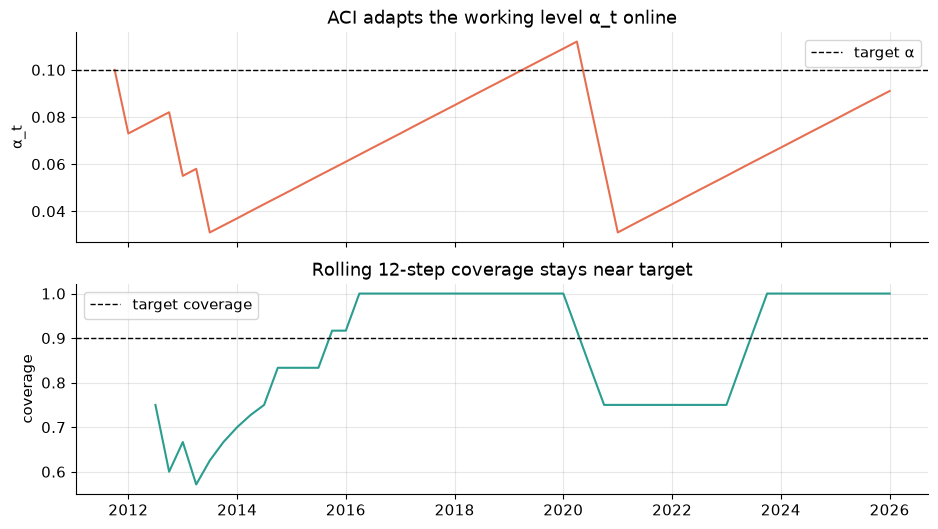

In [3]:
ets = C.ets_forecaster(trend="add", seasonal="add", seasonal_periods=4)
aci = P.aci_1step(y, ets, initial=30, alpha=alpha, gamma=0.03)
print("ACI realised coverage: %.2f  (target %.2f)" % (aci.attrs["coverage"], 1 - alpha))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
t = [pd.Period(s, freq="Q").to_timestamp(how="start") for s in aci["index"]]
axes[0].plot(t, aci.alpha_t, color="#e76f51")
axes[0].axhline(alpha, color="k", ls="--", lw=1, label="target α")
axes[0].set(title="ACI adapts the working level α_t online", ylabel="α_t"); axes[0].legend()
roll = (1 - aci.miss).rolling(12, min_periods=4).mean()
axes[1].plot(t, roll, color="#2a9d8f")
axes[1].axhline(1 - alpha, color="k", ls="--", lw=1, label="target coverage")
axes[1].set(title="Rolling 12-step coverage stays near target", ylabel="coverage"); axes[1].legend()
plt.show()

$\alpha_t$ breathes in and out as conditions change, and the rolling coverage tracks
the target instead of drifting off. **Use plain conformal for stable series; reach
for ACI when the regime can shift** (most real operational series).

---
**Next (03):** the capstone — rank every interval method by Winkler, and ship a
calibrated **fan chart**.